##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

**Load and merge datasets**

In [61]:
df_ship_inventory = pd.read_csv('ship_inventory.csv')
df_ship_inspection = pd.read_csv('ship_inspections_iter2.csv')

df_merged = df_ship_inventory.merge(df_ship_inspection, left_on="Ship_ID", right_on="Ship_ID", how="left")
df_merged.head()

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle


We have decided to merge the original version of ship inventory here, because in Iteration 1, we have cleaned the data by deleting NaN's, but that means we lost a lot of rows. With our new gained knowledge we decided it would be the best to start from the scratch and fill the missing values based on rest of the data.

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

Currently the data containts a lot of missing values mainly in columns Reactor_Power and Propulsion_Type. This not only makes it impossible to price ships, but also to evaluate the safety and risks of those ships.

**Business objective(s)**

The goal for this iteration is to find a reliable way on how to fill those missing values and make a data derived model that will predict the condition of the ship based on Propulsion_Type, Reactor_Power, Ship_Class, Galactic_Credits and Model_Cycle.

**Data mining goal(s)**

This is a manual classification model, because we are first taking a look at the data (using visulaizations) and then manually writing down the conditions and trying to get the best accuracy score.

**Success criteria**

Success criteria for the dataset is filling as much missing values with as much precise prediction as we can.
Success criteria for the model is beating the baseline prediction model.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [62]:
df_merged.info()
df_merged.duplicated(subset=["Ship_ID"]).sum()

<class 'pandas.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  str    
 4   Sector             368814 non-null  str    
 5   Hull_Integrity     368814 non-null  str    
 6   Reactor_Power      339345 non-null  float64
 7   Propulsion_Type    312108 non-null  str    
 8   Ship_Class         368814 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 25.3 MB


np.int64(500)

Looking at the data we can see that there are 368814 total rows. Out of those Model_Cycle is missing 7406 values, Reactor_Power is missing 29469 entries and Propulsion_Type is missing 56706 values. These missing values could potentionally skew with the statistics.

We also check for duplicates, which shows 500 of them.

In [63]:
df_merged = df_merged.drop_duplicates(subset=["Ship_ID"], keep="first")
df_merged.duplicated(subset=["Ship_ID"]).sum()

np.int64(0)

We start cleaning the data by first removing all the duplicates.

In [64]:
df_merged.describe()

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power
count,3.683140e+05,368314.000000,360916.000000,338876.000000
mean,7.311484e+09,19454.237615,7511.263984,71.592559
std,4.381194e+06,15542.661057,9.079721,44.644147
min,7.301583e+09,501.000000,7400.000000,30.000000
25%,7.308103e+09,7950.000000,7508.000000,40.000000
50%,7.312604e+09,15990.000000,7513.000000,60.000000
75%,7.315244e+09,27990.000000,7517.000000,80.000000
max,7.317101e+09,777777.000000,7522.000000,360.000000


Galactic Credits: The median price is 15990, but the mean is 19454, because of extreme outliers, as the maximum value is 777777. This is also reflected in the large standard deviation 15542.

Model Cycle: The ships range from cycle 7400 to 7522. The distribution is heavily skewed toward newer models, with 75% of the data concentrated between cycle 7508 and 7522.

Reactor Power: The power levels range from a minimum of 30 to a maximum of 360. While 75% of the ships have a reactor power of 80 or less, the maximum value of 360 indicates the presence of severe outliers on the high end.

In [65]:
df_merged["Ship_Manufacturer"].unique()

<StringArray>
[            'Galactic Motors',          'Republic Aerospace',
           'Nebula Industries',       'Corellian Engineering',
         'General Mining Corp',               'Hondo Systems',
 'Bayerische Motoren Wormhole',     'Independent Shipwrights',
            'Kuat Drive Yards',                 'Droid Works',
              'Mercurian Benz',            'Galactic Motors ',
               'Jumpship Corp',      'Independent Shipwright',
                 'Independent',                  'Kuat Drive',
             'Galactic_Motors',            'Ind. Shipwrights',
              'Corellian Eng.',           'Kuat  Drive Yards',
              'Galactic Motrs',                  'Nebula Ind',
  'Corellian Engineering Corp',                      'Nebula',
       'Nebula Industries (c)',        'Corelian Engineering',
             'GALACTIC MOTORS',                     'Kuat DY']
Length: 28, dtype: str

Since we will later be using Ship_Manufacturer and we need to correctly visualize the data, we will check for typos, different wording and other mistakes using unique.

In the result we can see there are quite a few mistakes so we will fix them in the next step.

In [66]:
normalize = {
    "Galactic Motors": "Galactic Motors",
    "Galactic Motors ": "Galactic Motors",
    "GALACTIC MOTORS": "Galactic Motors",
    "Galactic_Motors": "Galactic Motors",
    "Galactic Motrs": "Galactic Motors",

    "Republic Aerospace": "Republic Aerospace",

    "Nebula Industries": "Nebula Industries",
    "Nebula Industries (c)": "Nebula Industries",
    "Nebula Ind": "Nebula Industries",
    "Nebula": "Nebula Industries",

    "Corellian Engineering": "Corellian Engineering",
    "Corellian Engineering Corp": "Corellian Engineering",
    "Corellian Eng.": "Corellian Engineering",
    "Corelian Engineering": "Corellian Engineering",

    "General Mining Corp": "General Mining Corp",
    "Hondo Systems": "Hondo Systems",
    "Bayerische Motoren Wormhole": "Bayerische Motoren Wormhole",

    "Independent Shipwrights": "Independent Shipwrights",
    "Independent Shipwright": "Independent Shipwrights",
    "Ind. Shipwrights": "Independent Shipwrights",
    "Independent": "Independent Shipwrights",

    "Kuat Drive Yards": "Kuat Drive Yards",
    "Kuat  Drive Yards": "Kuat Drive Yards",
    "Kuat Drive": "Kuat Drive Yards",
    "Kuat DY": "Kuat Drive Yards",

    "Droid Works": "Droid Works",
    "Mercurian Benz": "Mercurian Benz",
    "Jumpship Corp": "Jumpship Corp",
}

df_merged["Ship_Manufacturer"] = (
    df_merged["Ship_Manufacturer"]
      .map(lambda x: normalize.get(x, x))
)

df_merged["Ship_Manufacturer"].unique()

<StringArray>
[            'Galactic Motors',          'Republic Aerospace',
           'Nebula Industries',       'Corellian Engineering',
         'General Mining Corp',               'Hondo Systems',
 'Bayerische Motoren Wormhole',     'Independent Shipwrights',
            'Kuat Drive Yards',                 'Droid Works',
              'Mercurian Benz',               'Jumpship Corp']
Length: 12, dtype: str

First we created a dictionary where we map all the mistakes to the correct version of the Ship_Manufacturer. After that we run through all the rows and check if the spelling is correct and in case it isn't we map it to the correct one.

By using the unique command again we check if we have correctly mapped all the Ship_Classes, which we did.

**Visualizations and patterns**


Hull_Integrity
Critical       80.966825
Operational    62.849822
Pristine       72.730196
Name: Reactor_Power, dtype: float64

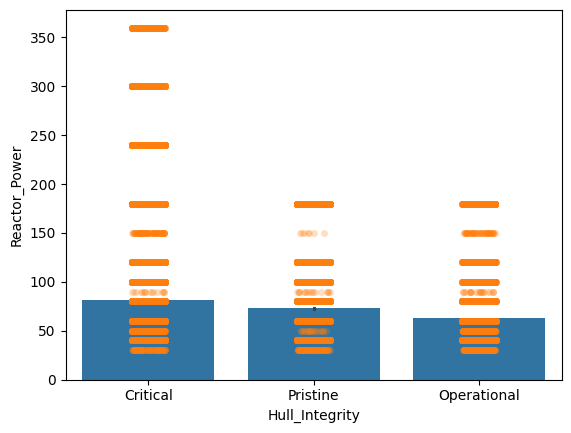

In [67]:
sns.barplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power", estimator='mean')
sns.stripplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power", alpha=0.25, jitter=True)
df_merged.groupby("Hull_Integrity")["Reactor_Power"].mean()


On this plot we can see that the reactors with more power are more likely to have a critical hull condition. We can also see that majority of outliers are in critical condition.

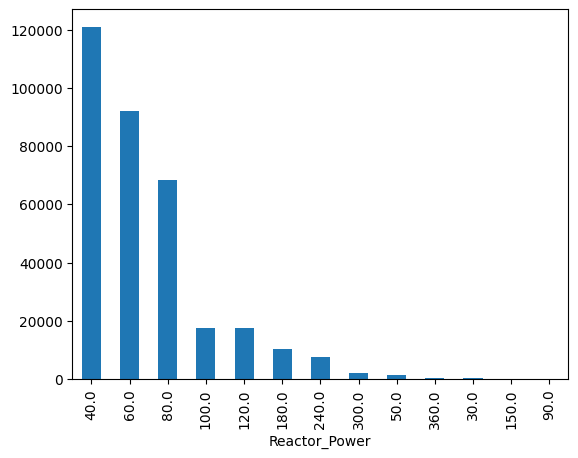

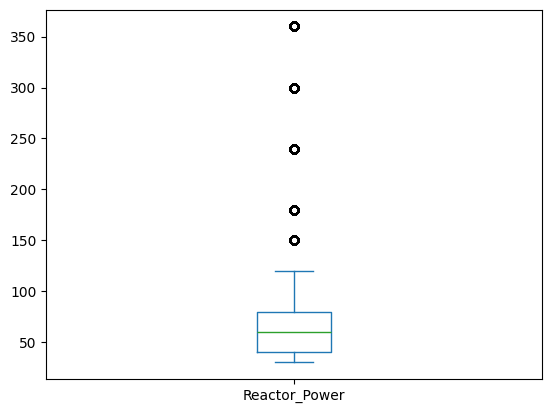

In [68]:
df_merged["Reactor_Power"].value_counts().plot.bar()
plt.show()

df_merged["Reactor_Power"].plot.box()
plt.show()


On the first plot we can see that majority of the ships are 80 or below reactor power. This bar blot doesnt really help us with identifying the outliers though, so we also chose to create a box plot. This seconnd plot clearly shows us that all the reactors above 120 reactor power are otliers and therefore we can classify them as illegal reactors.

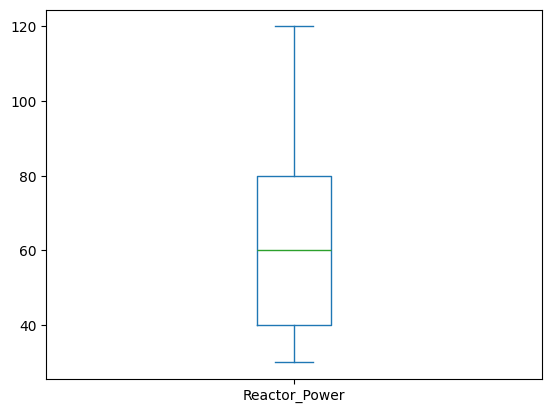

In [69]:
df_merged = df_merged[df_merged["Reactor_Power"] <= 120]
df_merged["Reactor_Power"].plot.box()
plt.show()


We have decided to remove all the reactors above 120 reacotr power, to prevent data skewage and to also adhere to safety risks by removing overclocked reactors.
On the box plot we can now clearly see all the outliers are gone.

<Axes: xlabel='Hull_Integrity'>

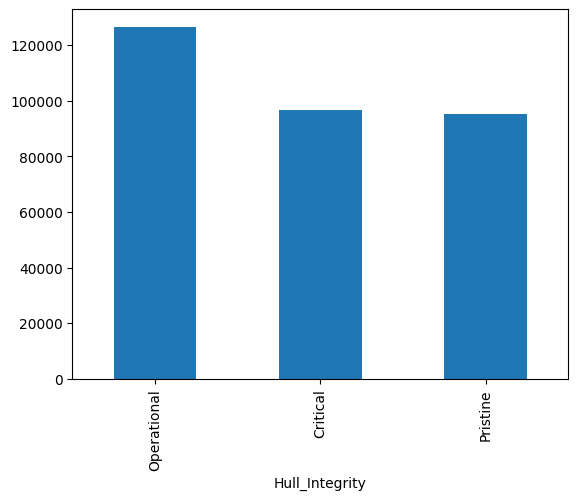

In [70]:
df_merged["Hull_Integrity"].value_counts().plot.bar()

This plot shows us that the majority of the ships are in operational condition.

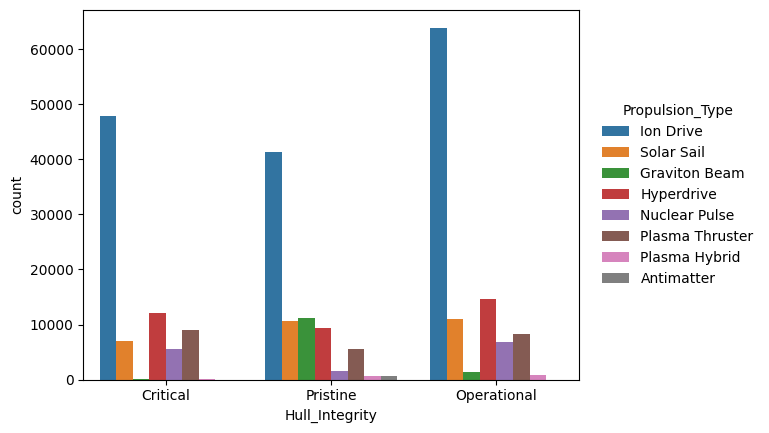

In [71]:
ax = sns.countplot(data=df_merged, x="Hull_Integrity", hue="Propulsion_Type")
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)


From this plot we can see that:
 * majority of Graviton Beam and Antimatter ships are in pristine condition
 * majority of Plasma Thruster Ships (by a tiny bit) are in critical condition

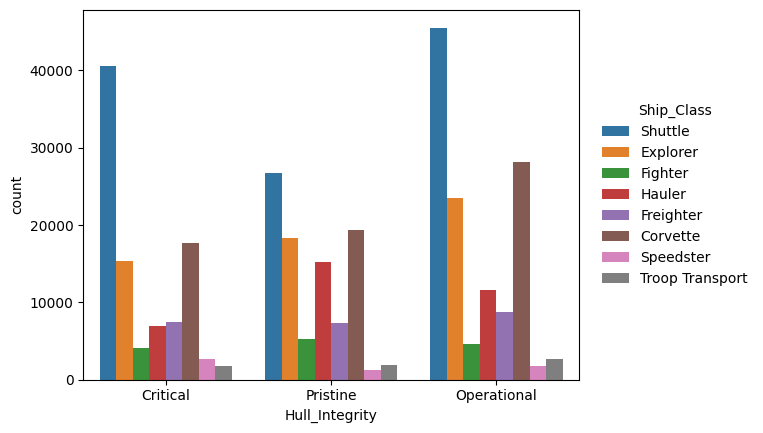

In [72]:
ax = sns.countplot(data=df_merged, x="Hull_Integrity", hue="Ship_Class")
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

From this plot we can see that:
 * majority of Hauler and Fighter ships are in pristine condition
 * majority of Speedster ships are in critical condition

Text(0.5, 1.0, 'Propulsion_Type distribution within each manufacturer')

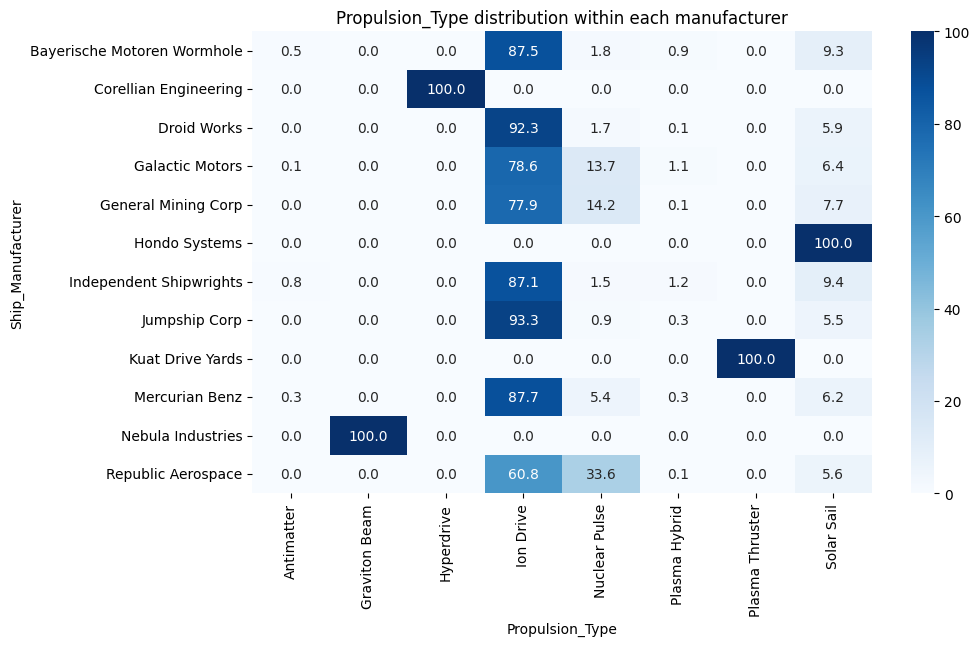

In [73]:
ct = pd.crosstab(df_merged["Ship_Manufacturer"], df_merged["Propulsion_Type"], normalize="index") * 100
plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Propulsion_Type distribution within each manufacturer")

Using this heatmap we can see  what propulsion types are the most common for what ship manufacturer. We can later use this information to fill in the missing values for the propulsion type by mapping the most common one for that ship manufacturer.

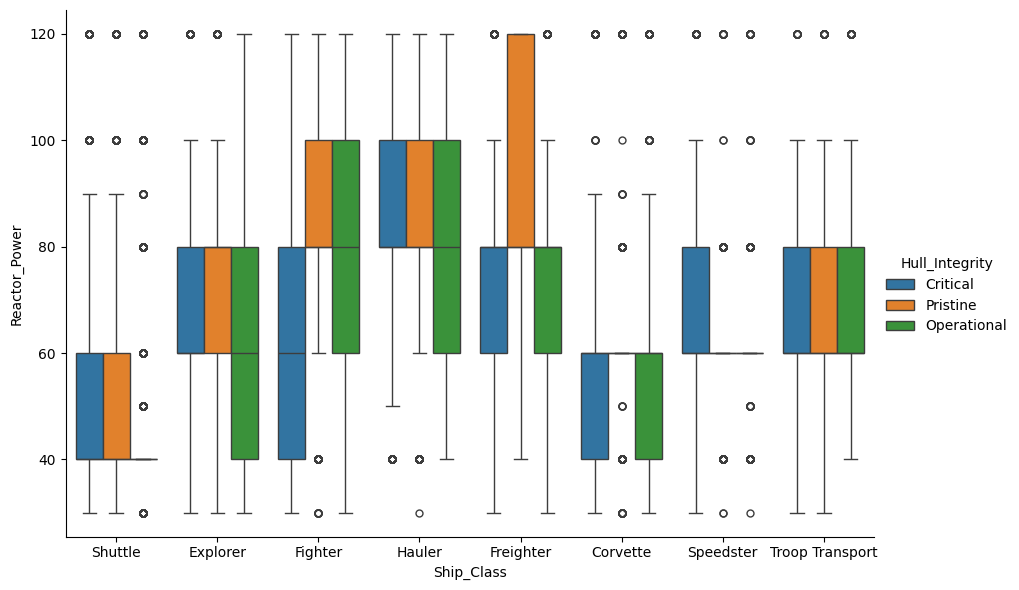

In [91]:
sns.catplot(
    data=df_merged,
    kind="box",
    x="Ship_Class",
    y="Reactor_Power",
    hue="Hull_Integrity",
    height=6,
    aspect=1.5,
    showfliers=True
)

Using this catplot we can filter hull integrity based on ship class and reactor power, which will be very useful during modelling.

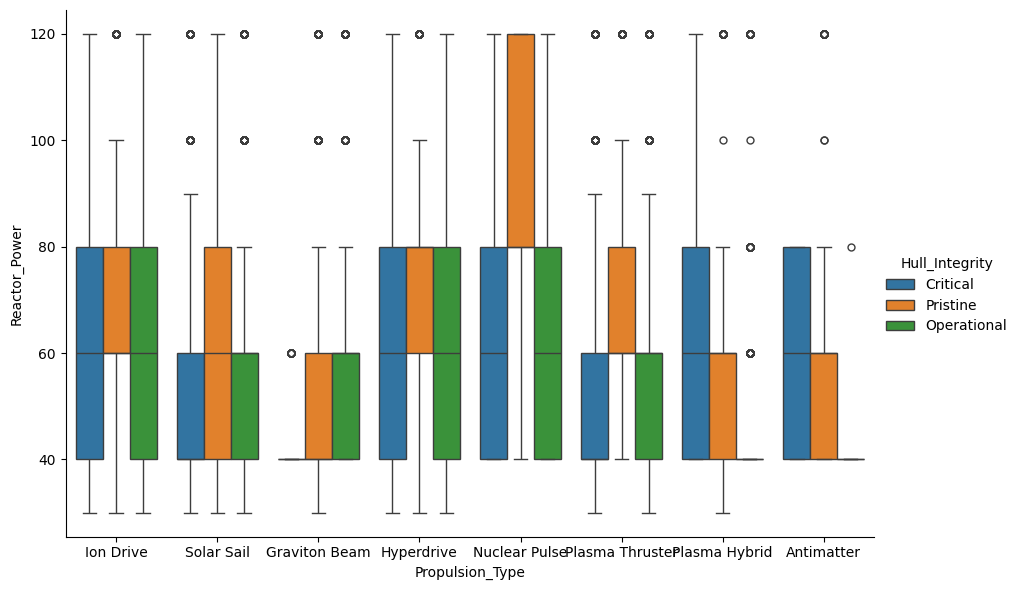

In [92]:
sns.catplot(
    data=df_merged,
    kind="box",
    x="Propulsion_Type",
    y="Reactor_Power",
    hue="Hull_Integrity",
    height=6,
    aspect=1.5,
    showfliers=True
)

Using this catplot we can filter hull integrity based on propulsion type and reactor power, which will again be very useful during modelling.

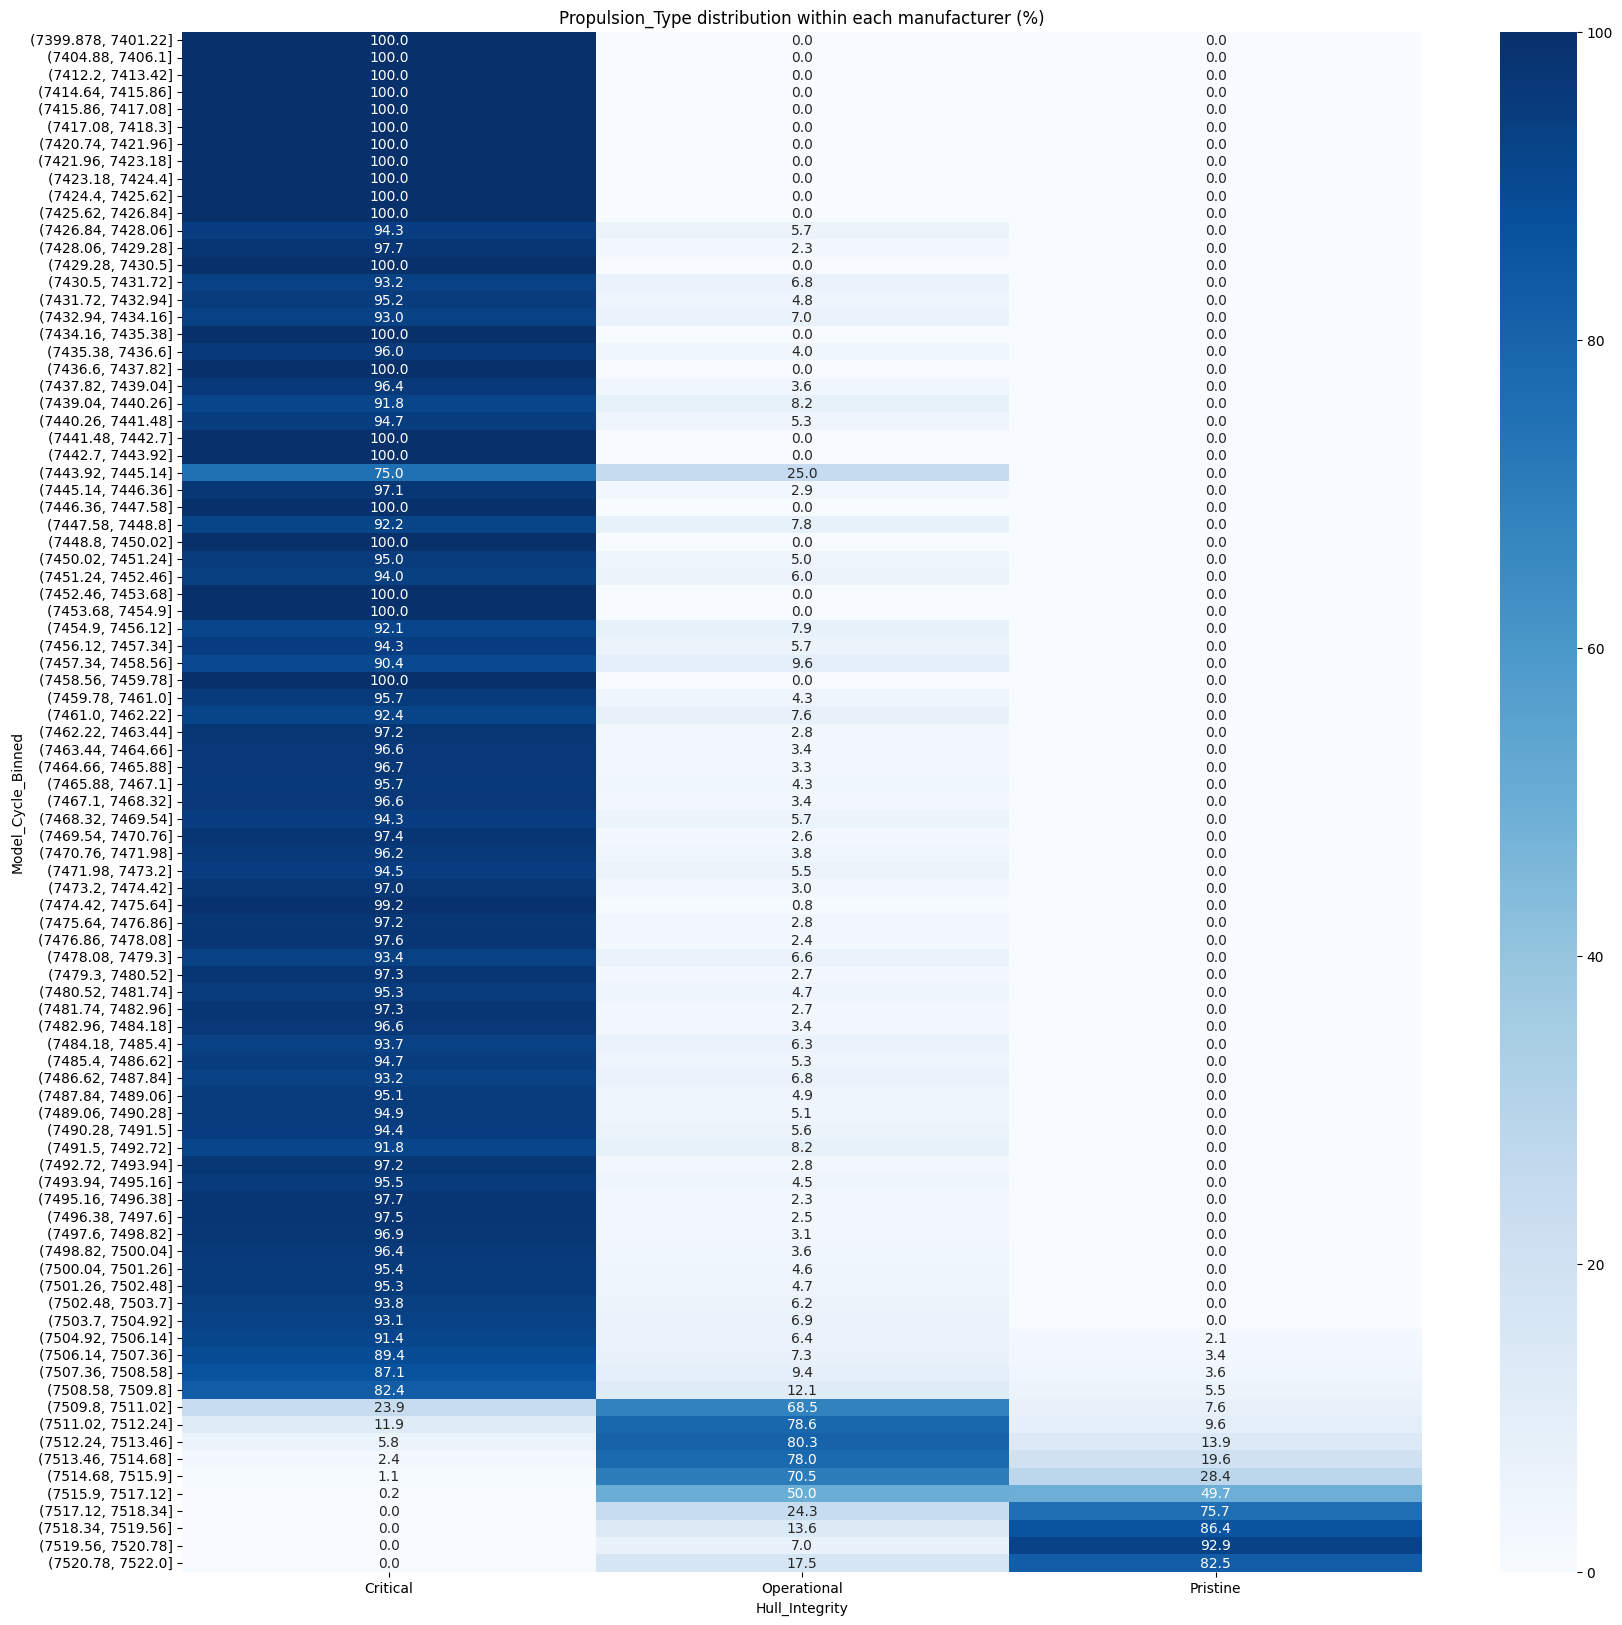

In [76]:
df_merged["Model_Cycle_Binned"] = pd.cut(df_merged["Model_Cycle"], bins=100)

ct = pd.crosstab(df_merged["Model_Cycle_Binned"], df_merged["Hull_Integrity"], normalize="index") * 100

plt.figure(figsize=(20, 20))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Propulsion_Type distribution within each manufacturer (%)")
plt.show()

Using the heatmap we can see the dristibution of ships with different hull integrity across different model years. It's very clear that ships below 7509.8 model cycle are very likely to be critical, while ships above 7517.12 are very likely to be in pristine condition. This filters a big chunk of data during the modelling, providing better results.

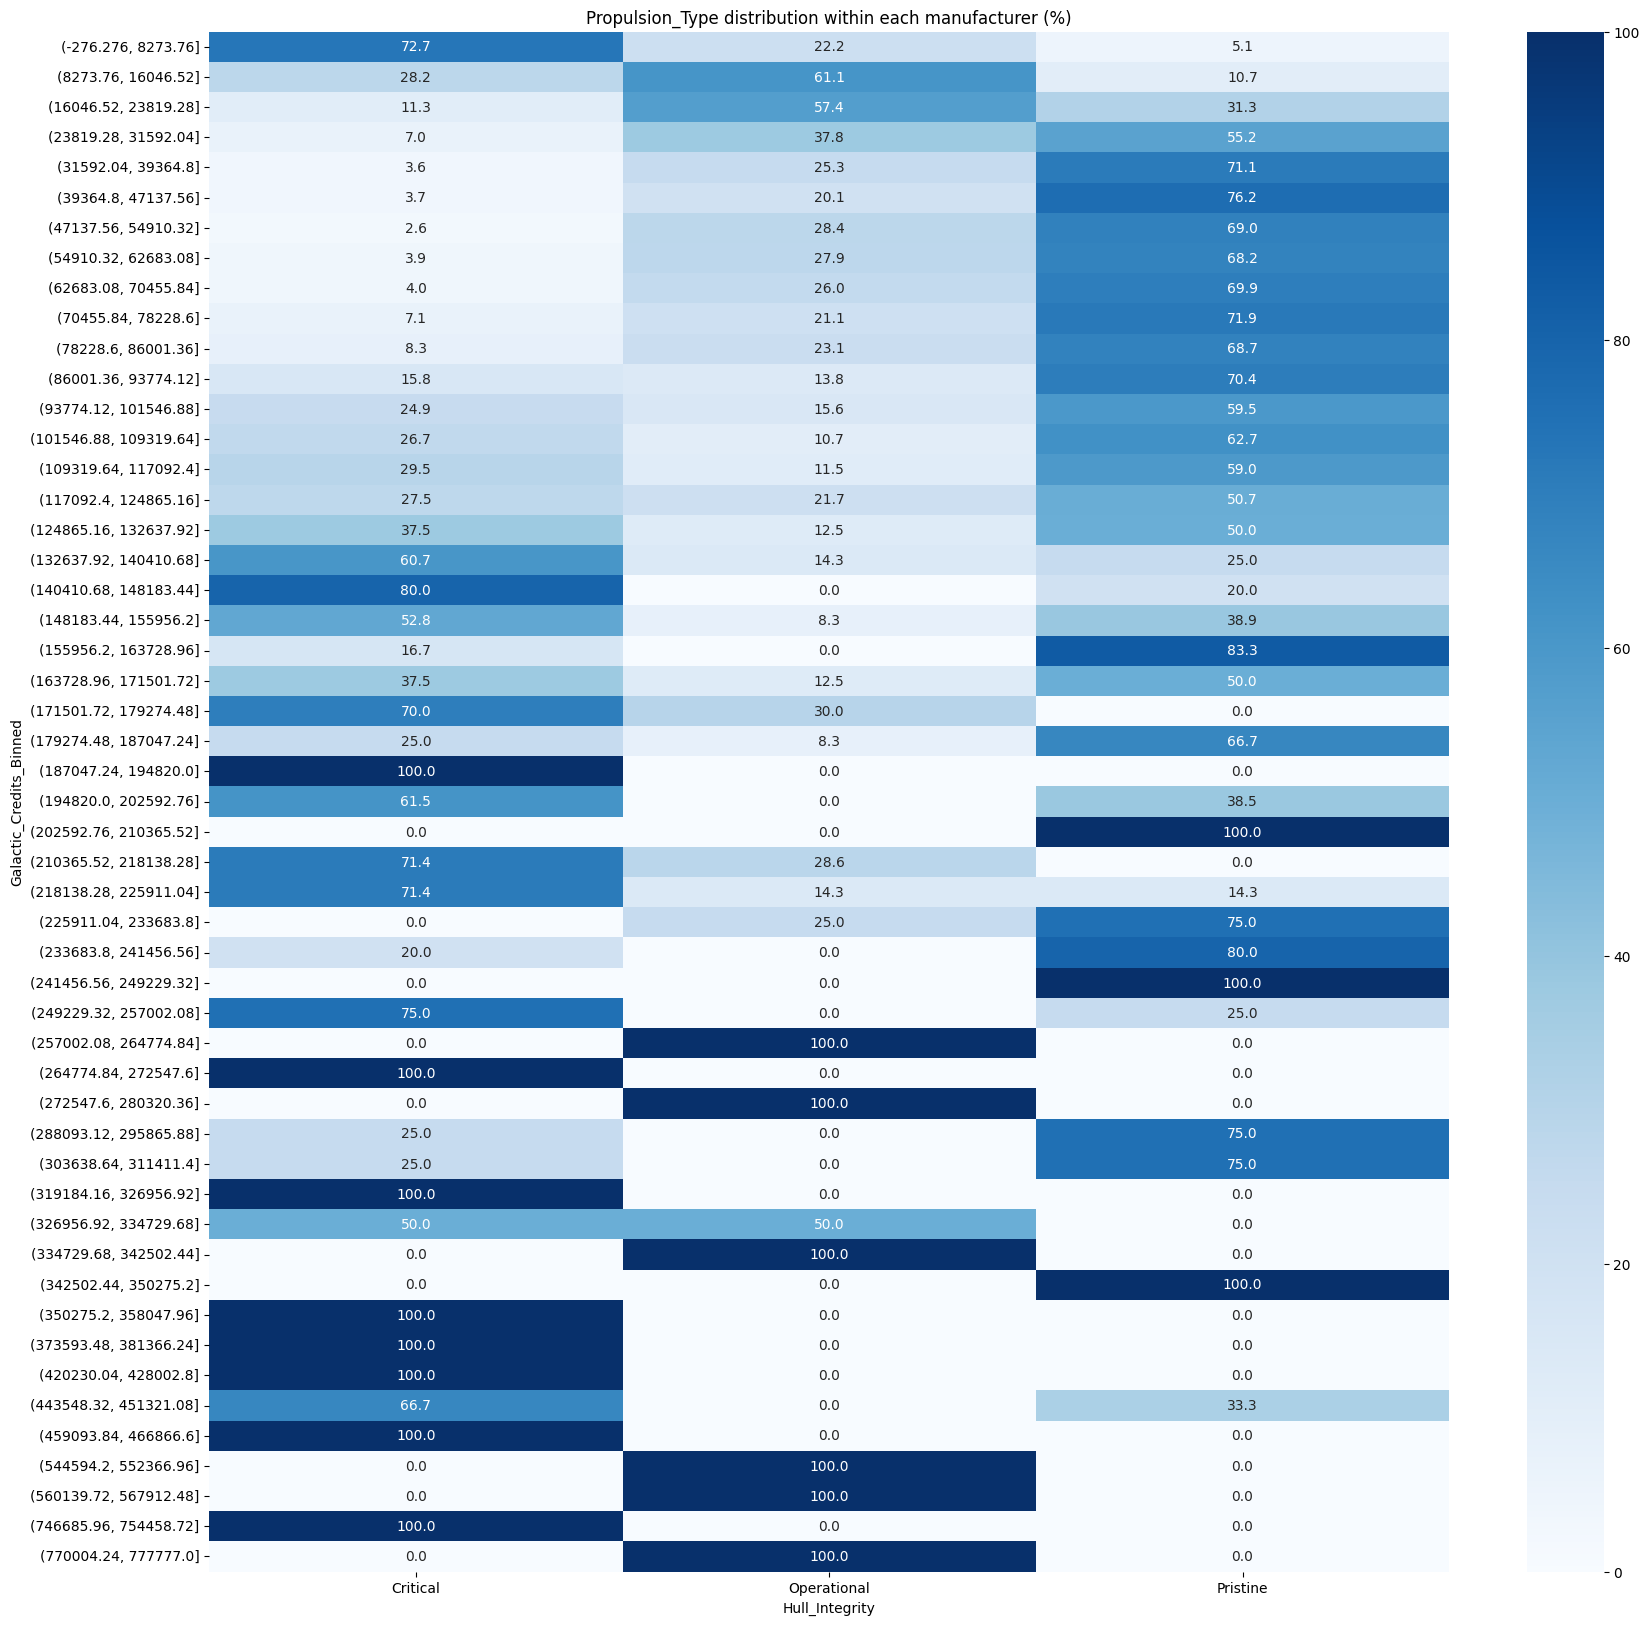

In [77]:
df_merged["Galactic_Credits_Binned"] = pd.cut(df_merged["Galactic_Credits"], bins=100)

ct = pd.crosstab(df_merged["Galactic_Credits_Binned"], df_merged["Hull_Integrity"], normalize="index") * 100

plt.figure(figsize=(20, 20))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Propulsion_Type distribution within each manufacturer (%)")
plt.show()

Using the heatmap we can see the dristibution of ships with different hull integrity across different price ranges. It's very clear that ships under 8200 are mostly critical, ships above 23000 and below 132000 are mostly pristine, ships between 350000 and 460000 are again mostly critical and all the ships outside these ranges have mixed integrity.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [78]:
df_merged = df_merged.dropna(subset=["Model_Cycle"])
df_merged.info()

<class 'pandas.DataFrame'>
Index: 311877 entries, 0 to 368813
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   Ship_ID                  311877 non-null  int64   
 1   Galactic_Credits         311877 non-null  int64   
 2   Model_Cycle              311877 non-null  float64 
 3   Ship_Manufacturer        311877 non-null  str     
 4   Sector                   311877 non-null  str     
 5   Hull_Integrity           311877 non-null  str     
 6   Reactor_Power            311877 non-null  float64 
 7   Propulsion_Type          263865 non-null  str     
 8   Ship_Class               311877 non-null  str     
 9   Model_Cycle_Binned       311877 non-null  category
 10  Galactic_Credits_Binned  311877 non-null  category
dtypes: category(2), float64(2), int64(2), str(5)
memory usage: 24.4 MB


In [79]:
by_mfr_mode = (
    df_merged.dropna(subset=["Ship_Manufacturer", "Propulsion_Type"])
      .groupby("Ship_Manufacturer")["Propulsion_Type"]
      .agg(lambda s: s.value_counts().idxmax())
)
global_mode = df_merged["Propulsion_Type"].mode().iloc[0]
missing = df_merged["Propulsion_Type"].isna()
df_merged.loc[missing, "Propulsion_Type"] = (
    df_merged.loc[missing, "Ship_Manufacturer"].map(by_mfr_mode).fillna(global_mode)
)

df_merged.info()

<class 'pandas.DataFrame'>
Index: 311877 entries, 0 to 368813
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   Ship_ID                  311877 non-null  int64   
 1   Galactic_Credits         311877 non-null  int64   
 2   Model_Cycle              311877 non-null  float64 
 3   Ship_Manufacturer        311877 non-null  str     
 4   Sector                   311877 non-null  str     
 5   Hull_Integrity           311877 non-null  str     
 6   Reactor_Power            311877 non-null  float64 
 7   Propulsion_Type          311877 non-null  str     
 8   Ship_Class               311877 non-null  str     
 9   Model_Cycle_Binned       311877 non-null  category
 10  Galactic_Credits_Binned  311877 non-null  category
dtypes: category(2), float64(2), int64(2), str(5)
memory usage: 24.4 MB


In [80]:
mean_by_integrity = (
    df_merged.dropna(subset=["Hull_Integrity", "Reactor_Power"])
      .groupby("Hull_Integrity")["Reactor_Power"]
      .mean()
)
global_mean = df_merged["Reactor_Power"].mean()
mask = df_merged["Reactor_Power"].isna()
df_merged.loc[mask, "Reactor_Power"] = (
    df_merged.loc[mask, "Hull_Integrity"].map(mean_by_integrity).fillna(global_mean)
)

df_merged.info()

<class 'pandas.DataFrame'>
Index: 311877 entries, 0 to 368813
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   Ship_ID                  311877 non-null  int64   
 1   Galactic_Credits         311877 non-null  int64   
 2   Model_Cycle              311877 non-null  float64 
 3   Ship_Manufacturer        311877 non-null  str     
 4   Sector                   311877 non-null  str     
 5   Hull_Integrity           311877 non-null  str     
 6   Reactor_Power            311877 non-null  float64 
 7   Propulsion_Type          311877 non-null  str     
 8   Ship_Class               311877 non-null  str     
 9   Model_Cycle_Binned       311877 non-null  category
 10  Galactic_Credits_Binned  311877 non-null  category
dtypes: category(2), float64(2), int64(2), str(5)
memory usage: 24.4 MB


**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [81]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [82]:
target = df_merged["Hull_Integrity"]

features = df_merged[["Reactor_Power", "Propulsion_Type", "Ship_Class", "Galactic_Credits", "Model_Cycle"]]

feature_train, feature_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=2)

In [83]:
value = "Operational"

pred_train = [value] * len(target_train)

pred_test = [value] * len(target_test)

In [84]:
print("The length of y_train is:", len(target_train))
print("The length of y_test is:", len(target_test))

The length of y_train is: 233907
The length of y_test is: 77970


In [85]:
print("Accuracy of train set:", accuracy_score(pred_train, target_train))
print("Accuracy of test set:", accuracy_score(pred_test, target_test))

Accuracy of train set: 0.39762811715767377
Accuracy of test set: 0.39772989611389


In [125]:
def classification_model(row):
    rp = row["Reactor_Power"]
    pt = row["Propulsion_Type"]
    sc = row["Ship_Class"]
    gc = row["Galactic_Credits"]
    mc = row["Model_Cycle"]
    
    if mc <= 7509.8: 
        return "Critical"
    
    if mc >= 7517.12:
        return "Pristine"
        
    if gc > 350000 and gc < 460000:
        return "Critical"
        
    if gc >= 23819 and gc < 132000:
        return "Pristine"
        
    if gc <= 8273:
        return "Critical"
        
    if pt in ("Graviton Beam", "Antimatter"):
        return "Pristine"
    
    if pt == "Plasma Thruster":
        if rp > 60:
            return "Pristine"
        else:  
            return "Critical"
    
    if pt == "Nuclear Pulse":
        if rp > 80: 
            return "Pristine"
        
    
    if sc == "Freighter":
        if rp >= 80:
            return "Pristine"
        else:
            return "Critical"
    
    if sc in ("Fighter", "Speedster"):
        return "Critical"

    
    return "Operational"


**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [126]:
feature_train["Prediction"] = feature_train.apply(lambda row: classification_model(row), axis=1)
feature_test["Prediction"] = feature_test.apply(lambda row: classification_model(row), axis=1)

In [127]:
print("Accuracy of train set:", accuracy_score(feature_train["Prediction"], target_train))
print("Accuracy of test set:", accuracy_score(feature_test["Prediction"], target_test))

Accuracy of train set: 0.7272206475223059
Accuracy of test set: 0.7278568680261639


In [128]:
print("Recall of train set:", recall_score(feature_train["Prediction"], target_train, average=None))
print("Recall of test set:", recall_score(feature_test["Prediction"], target_test, average=None))

Recall of train set: [0.71776069 0.8401327  0.67430014]
Recall of test set: [0.71802271 0.84251442 0.67471222]


In [129]:
target_names=["Critical", "Operational", "Pristine"]

print(classification_report(feature_train["Prediction"], target_train, target_names=target_names))
print(classification_report(feature_test["Prediction"], target_test, target_names=target_names))

              precision    recall  f1-score   support

    Critical       0.96      0.72      0.82     95047
 Operational       0.45      0.84      0.59     49735
    Pristine       0.86      0.67      0.75     89125

    accuracy                           0.73    233907
   macro avg       0.76      0.74      0.72    233907
weighted avg       0.81      0.73      0.75    233907

              precision    recall  f1-score   support

    Critical       0.96      0.72      0.82     31882
 Operational       0.45      0.84      0.58     16465
    Pristine       0.86      0.67      0.76     29623

    accuracy                           0.73     77970
   macro avg       0.76      0.75      0.72     77970
weighted avg       0.82      0.73      0.75     77970



---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |